In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("C:/Users/Administrator/Downloads/financial_loan (2) (3).xlsx")

In [5]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

# Monthly Loan Applications Trend

In [6]:
monthly_applications = (
    df.groupby(df["issue_date"].dt.to_period("M"))["id"]
      .nunique()
      .reset_index()
)

monthly_applications.columns = ["Month", "Loan_Applications"]

monthly_applications["Month"] = monthly_applications["Month"].astype(str)

print(monthly_applications)

      Month  Loan_Applications
0   2021-01               2332
1   2021-02               2279
2   2021-03               2627
3   2021-04               2755
4   2021-05               2911
5   2021-06               3184
6   2021-07               3366
7   2021-08               3441
8   2021-09               3536
9   2021-10               3796
10  2021-11               4035
11  2021-12               4314


# Line Chart

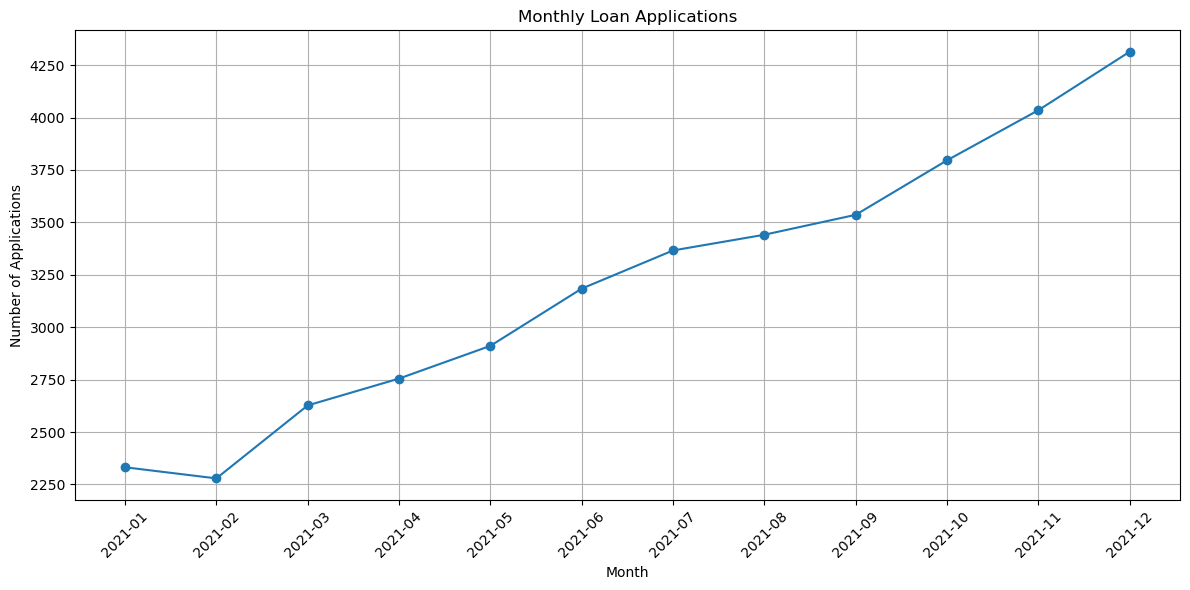

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_applications["Month"],
    monthly_applications["Loan_Applications"],
    marker="o"
)

plt.title("Monthly Loan Applications")
plt.xlabel("Month")
plt.ylabel("Number of Applications")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

# Regional Analysis — State

In [8]:
state_analysis = (
    df.groupby("address_state")["id"]
      .nunique()
      .sort_values(ascending=False)
)

print(state_analysis)

address_state
CA    6894
NY    3701
FL    2773
TX    2664
NJ    1822
IL    1486
PA    1482
VA    1375
GA    1355
MA    1310
OH    1188
MD    1027
AZ     833
WA     805
CO     770
NC     759
CT     730
MI     685
MO     660
MN     592
NV     482
SC     464
WI     446
OR     436
AL     432
LA     426
KY     320
OK     293
KS     260
UT     252
AR     236
DC     214
RI     196
NM     183
HI     170
WV     167
NH     161
DE     110
MT      79
WY      79
AK      78
SD      63
VT      54
MS      19
TN      17
IN       9
ID       6
NE       5
IA       5
ME       3
Name: id, dtype: int64


# Bar Chart

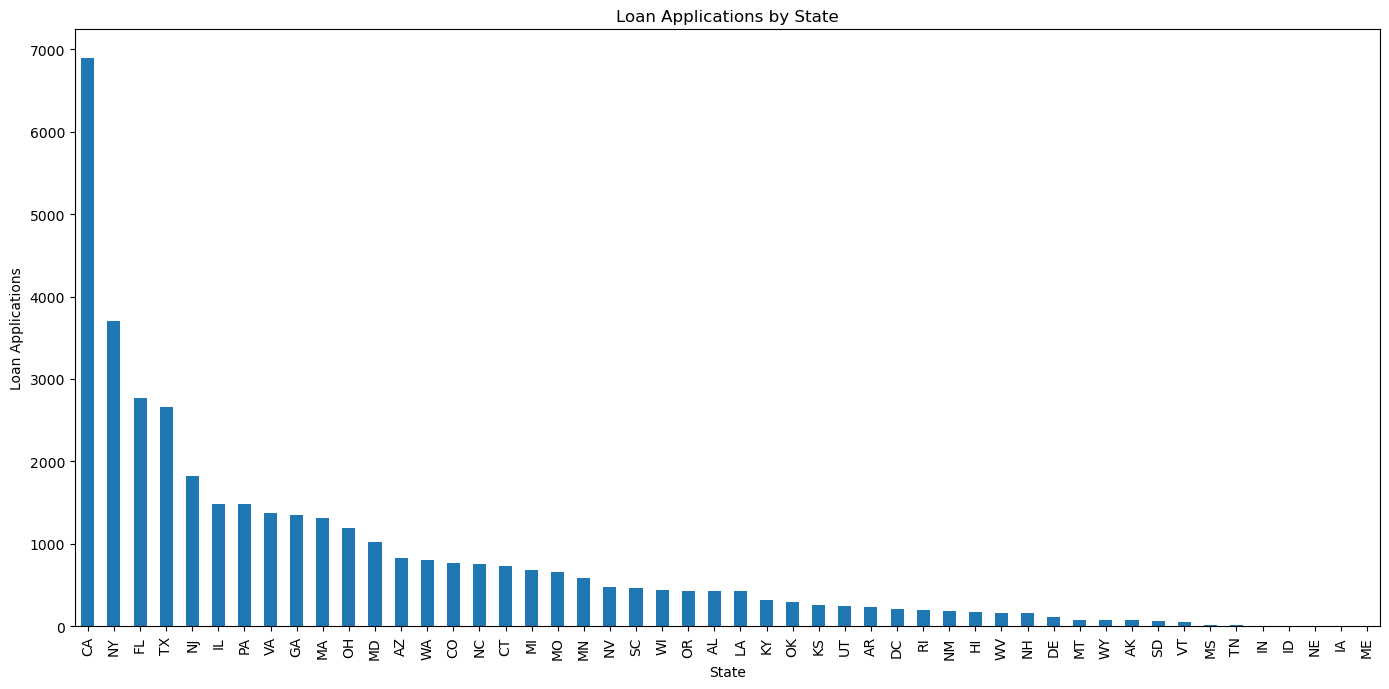

In [9]:
plt.figure(figsize=(14, 7))

state_analysis.plot(kind="bar")

plt.title("Loan Applications by State")
plt.xlabel("State")
plt.ylabel("Loan Applications")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# loan Term Analysis

In [10]:
term_analysis = (
    df.groupby("term")["id"]
      .nunique()
)

print(term_analysis)

term
36 months    28237
60 months    10339
Name: id, dtype: int64


# Pie Chart

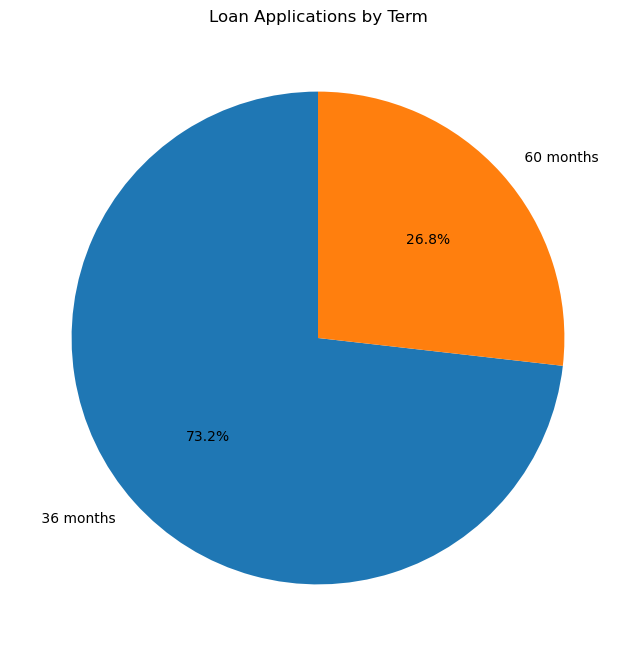

In [11]:
plt.figure(figsize=(8, 8))

plt.pie(
    term_analysis.values,
    labels=term_analysis.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Loan Applications by Term")

plt.show()

# Employee Length Analysis

In [12]:
emp_length_analysis = (
    df.groupby("emp_length")["id"]
      .nunique()
      .sort_values(ascending=False)
)

print(emp_length_analysis)

emp_length
10+ years    8870
< 1 year     4575
2 years      4382
3 years      4088
4 years      3428
5 years      3273
1 year       3229
6 years      2228
7 years      1772
8 years      1476
9 years      1255
Name: id, dtype: int64


# Bar Chart

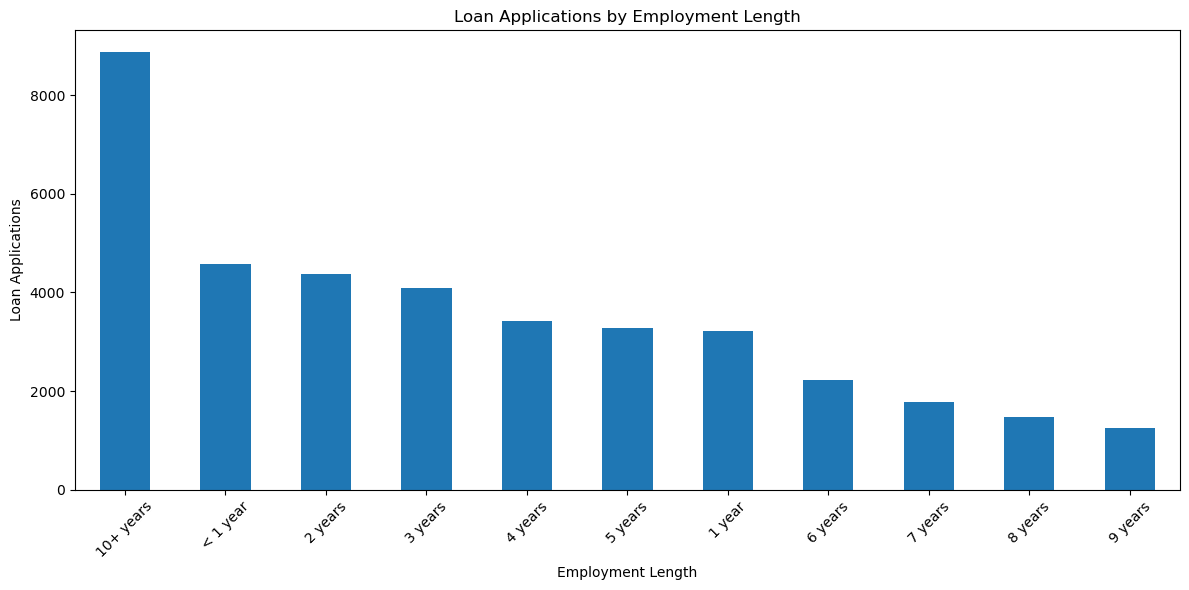

In [13]:
plt.figure(figsize=(12, 6))

emp_length_analysis.plot(kind="bar")

plt.title("Loan Applications by Employment Length")
plt.xlabel("Employment Length")
plt.ylabel("Loan Applications")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Loan Purpose BreakDown

In [14]:
purpose_analysis = (
    df.groupby("purpose")["id"]
      .nunique()
      .sort_values(ascending=False)
)

print(purpose_analysis)

purpose
Debt consolidation    18214
credit card            4998
other                  3824
home improvement       2876
major purchase         2110
small business         1776
car                    1497
wedding                 928
medical                 667
moving                  559
house                   366
vacation                352
educational             315
renewable_energy         94
Name: id, dtype: int64


# Horizontal Bar Chart

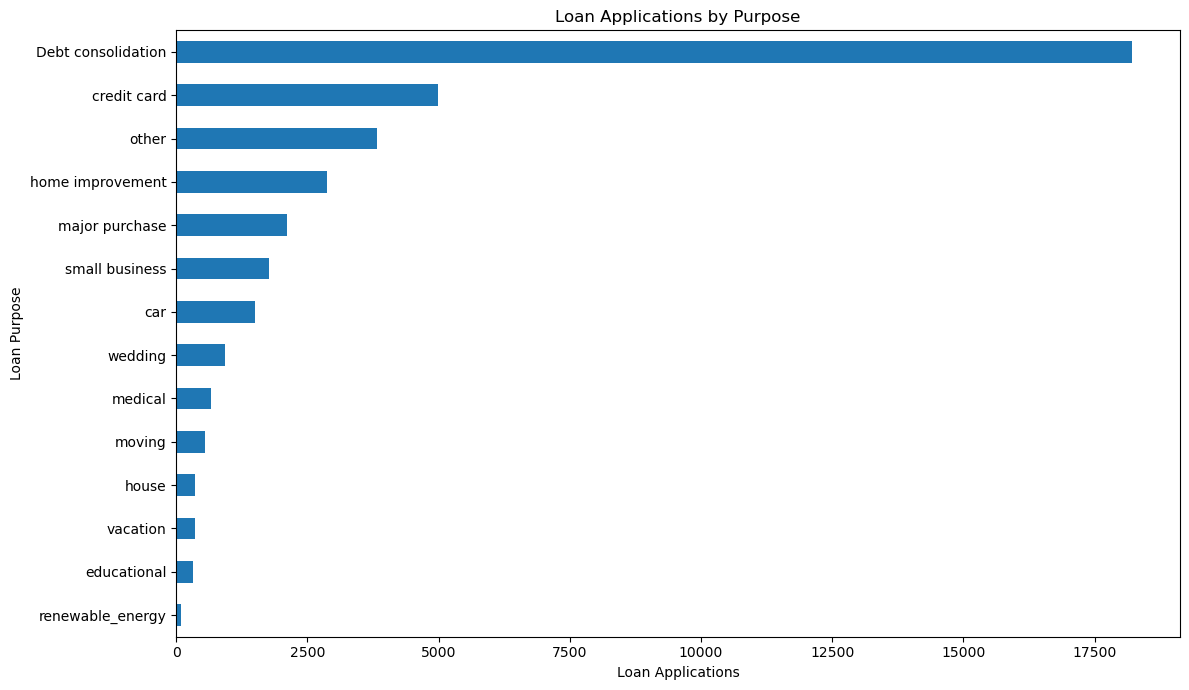

In [15]:
plt.figure(figsize=(12, 7))

purpose_analysis.sort_values().plot(kind="barh")

plt.title("Loan Applications by Purpose")
plt.xlabel("Loan Applications")
plt.ylabel("Loan Purpose")

plt.tight_layout()
plt.show()

# Home Ownership Analysis

In [16]:
home_ownership_analysis = (
    df.groupby("home_ownership")["id"]
      .nunique()
      .sort_values(ascending=False)
)

print(home_ownership_analysis)

home_ownership
RENT        18439
MORTGAGE    17198
OWN          2838
OTHER          98
NONE            3
Name: id, dtype: int64


# Bar Chart

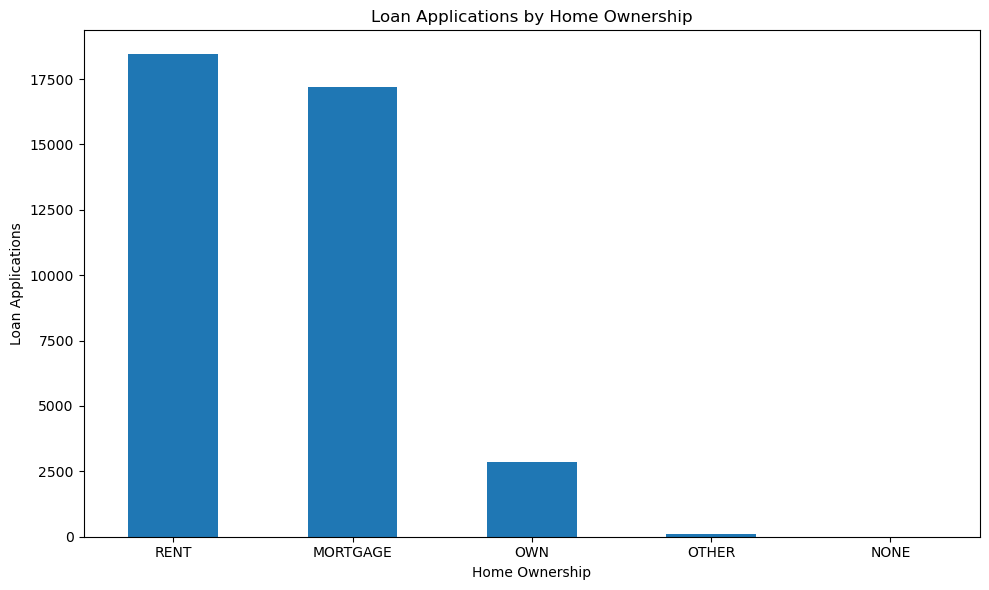

In [17]:
plt.figure(figsize=(10, 6))

home_ownership_analysis.plot(kind="bar")

plt.title("Loan Applications by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Loan Applications")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Heat Map 

## Home Ownership summary

In [18]:
home_analysis = df.groupby("home_ownership").agg(
    Loan_Applications=("id", "nunique"),
    Funded_Amount=("loan_amount", "sum"),
    Amount_Received=("total_payment", "sum")
).reset_index()

print(home_analysis)

  home_ownership  Loan_Applications  Funded_Amount  Amount_Received
0       MORTGAGE              17198      219329150        238474438
1           NONE                  3          16800            19053
2          OTHER                 98        1044975          1025257
3            OWN               2838       29597675         31729129
4           RENT              18439      185768475        201823056


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = home_analysis.set_index("home_ownership")

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=",",
    linewidths=0.5
)

plt.title("Loan Analysis by Home Ownership")
plt.xlabel("Loan Metrics")
plt.ylabel("Home Ownership")

plt.tight_layout()
plt.show()